In [8]:
import itertools
import functools
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import xarray as xr

from fluxoniumcr import DATA_DIR


plt.style.use("fluxoniumcr.plotting.paper")

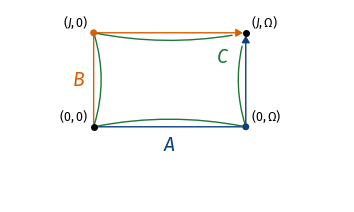

In [9]:
fig, ax = plt.subplots(
    figsize=(85/25.4, 49/25.4),
)

color0 = 'C0'
color1 = 'C1'
color2 = 'C7'

ax.scatter(
    [0, 1],
    [0, 1],
    c='black',
    zorder=10,
    marker='.',
    s=64,
)
ax.scatter(
    [1, 0],
    [0, 1],
    c=[color0, color1],
    zorder=10,
    marker='.',
    s=64,
)
# plt.plot([0, 1, 1], [0, 0, 1], c='C0')

arrowprops = dict(
    arrowstyle="-|>,head_width=0.12,head_length=0.20784",
    mutation_scale=20,
    linewidth=plt.rcParams['lines.linewidth'],
)


ax.annotate(
    "",
    xytext=(0, 0),
    xy=(1, 0),
    arrowprops=dict(arrowprops, arrowstyle="-", color=color0),#, connectionstyle='arc3,rad=0.0'),
)
ax.annotate(
    "",
    xytext=(1, 0),
    xy=(1, 1),
    arrowprops=dict(arrowprops, color=color0),#, connectionstyle='arc3,rad=0.0'),
)

ax.annotate(
    "",
    xytext=(0, 0),
    xy=(0, 1),
    arrowprops=dict(arrowprops, arrowstyle="-", color=color1),#, connectionstyle='arc3,rad=-0.0'),
)
ax.annotate(
    "",
    xytext=(0, 1),
    xy=(1, 1),
    arrowprops=dict(arrowprops, color=color1),#, connectionstyle='arc3,rad=-0.0'),
)


for i in range(3):
    xytext = (0, -6)
    if i == 0:
        xy = (0.5, 0.0)
        ha = 'center'
        va = 'top'
    elif i == 1:
        xy = (0, 0.5)
        xytext = xytext[::-1]
        ha = 'right'
        va = 'center'
    elif i == 2:
        xy = (1, 1)
        xytext = (-12, -10)
        ha = 'right'
        va = 'top'
        
    ax.annotate(
        ["$A$", "$B$", "$C$"][i],
        xytext=xytext,
        xy=xy,
        textcoords='offset points',
        c=[color0, color1, color2][i],
        fontsize=14,
        ha=ha,
        va=va,
    )


for i in range(4):
    text = [
        r"$(0, 0)$",
        r"$(0, \Omega)$",
        r"$(J, 0)$",
        r"$(J, \Omega)$",
    ][i]
    pad = 2
    x_pad = 2
    xytext = [
        (-pad - x_pad, pad),
        (pad + x_pad,  pad),
        (-pad - x_pad, pad),
        (pad + x_pad, pad),
    ][i]
    ha = ['right', 'left', 'right', 'left'][i]
    va = ['bottom', 'bottom', 'bottom', 'bottom'][i]
    xy = [
        (0, 0),
        (1, 0),
        (0, 1),
        (1, 1),
    ][i]
        
    ax.annotate(
        text,
        xytext=xytext,
        xy=xy,
        textcoords='offset points',
        c='black',
#         fontsize=12,
        ha=ha,
        va=va,
    )
    

aspect = 1/1.618
ax.set_aspect(aspect)
ax.set_xlim(-0.55, 1.65)
ax.set_ylim(-0.8, 1.25)


# pad_x = 0.1
# ax.plot(
#     [[0, 0.5 + pad_x], [0.5 - pad_x, 1.0]],
#     [[0, 0], [0, 0]],
#     lw=arrowprops['linewidth'],
#     c=color0,
# )

# pad_y = 0.11
# ax.plot(
#     [[0, 0], [0, 0]],
#     [[0, 0.5 + pad_y/aspect], [0.5 - pad_y/aspect, 1.0]],
#     lw=arrowprops['linewidth'],
#     c=color1,
# )

# pad_x = 0.07
# pad_y = 0.07
# ax.plot(
#     pad_x + (1-2*pad_x) * np.array([1, 1, 0, 0, 1]),
#     pad_y/aspect + (1-2*pad_y/aspect) * np.array([1, 0, 0, 1, 1]),
#     lw=arrowprops['linewidth'],
#     c='C2'
# )

ax.annotate(
    "",
    xytext=(1, 1),
    xy=(1, 0),
    arrowprops=dict(arrowprops, arrowstyle="-", shrinkA=10, color=color2, connectionstyle='arc3,rad=0.16'),
)
ax.annotate(
    "",
    xytext=(1, 0),
    xy=(0, 0),
    arrowprops=dict(arrowprops, arrowstyle="-", color=color2,  connectionstyle='arc3,rad=0.1'),
)
ax.annotate(
    "",
    xytext=(0, 0),
    xy=(0, 1),
    arrowprops=dict(arrowprops, arrowstyle="-", color=color2,  connectionstyle='arc3,rad=0.16'),
)
ax.annotate(
    "",
    xytext=(0, 1),
    xy=(1, 1),
    arrowprops=dict(arrowprops, arrowstyle="-", shrinkB=10, color=color2, connectionstyle='arc3,rad=0.1'),
)

ax.set_axis_off()

fig.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
)

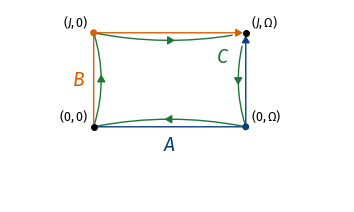

In [10]:
trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        0.5,
        0.0,
        ax.transData,
    )
)
triangle = mpl.patches.RegularPolygon(
    (0, 0.076),
    3,
    radius=0.04,
    orientation=np.pi/3 - np.pi/2,
    transform=trans,
    fc=color2,
    ec=color2,
    linewidth=plt.rcParams['lines.linewidth'],
    zorder=10,
    joinstyle='round',
)
ax.add_patch(triangle)

trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        0.5,
        1.0,
        ax.transData,
    )
)
triangle = mpl.patches.RegularPolygon(
    (0, -0.076),
    3,
    radius=0.04,
    orientation=np.pi/3 + np.pi/2,
    transform=trans,
    fc=color2,
    ec=color2,
    zorder=10,
    joinstyle='round',
)
ax.add_patch(triangle)

trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        0.0,
        0.5,
        ax.transData,
    )
)
triangle = mpl.patches.RegularPolygon(
    (0.076, 0),
    3,
    radius=0.04,
    orientation=-2*np.pi/3,
    transform=trans,
    fc=color2,
    ec=color2,
    zorder=10,
    joinstyle='round',
)
ax.add_patch(triangle)

trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        1.0,
        0.5,
        ax.transData,
    )
)
triangle = mpl.patches.RegularPolygon(
    (-0.076, 0),
    3,
    radius=0.04,
    orientation=np.pi/3,
    transform=trans,
    fc=color2,
    ec=color2,
    zorder=10,
    joinstyle='round',
)
ax.add_patch(triangle)


fig

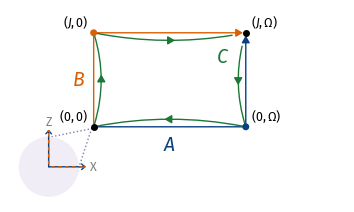

In [11]:
trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        0.0,
        0.0,
        ax.transData,
    )
)
bloch_sphere_color = "#f1edf7"
bloch_dark_color = "#8b79a6"
circle = mpl.patches.Circle(
    (-0.45, -0.4),
    0.3,
    transform=trans,
    fc=bloch_sphere_color,
    ec='none',
    zorder=10,
)
ax.add_patch(circle)

gray_color = 'gray'
z_axis = mpl.patches.FancyArrowPatch(
    posA=(-0.45, -0.4),
    posB=(-0.45, 0.0),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color0,
    zorder=100,
)
ax.add_patch(z_axis)
x_axis = mpl.patches.FancyArrowPatch(
    posA=(-0.45, -0.4),
    posB=(-0.05, -0.4),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color0,
    zorder=100,
)
ax.add_patch(x_axis)
gray_color = 'gray'
z_axis = mpl.patches.FancyArrowPatch(
    posA=(-0.45, -0.4),
    posB=(-0.45, 0.0),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    ls=(3.2, (2.5, 2.5)),
    shrinkA=0.0,
#     shrinkB=4,
    color=color1,
    capstyle='butt',
    zorder=101,
)
ax.add_patch(z_axis)
x_axis = mpl.patches.FancyArrowPatch(
    posA=(-0.45, -0.4),
    posB=(-0.05, -0.4),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    ls=(3.2, (2.5, 2.5)),
    shrinkA=0.0,
#     shrinkB=4,
    color=color1,
    capstyle='butt',
    zorder=101,
)
ax.add_patch(x_axis)


z_label = mpl.text.Text(
    x=-0.45,
    y=0.05,
    text="Z",
    transform=trans,
    color=gray_color,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(z_label)

x_label = mpl.text.Text(
    x=0.0,
    y=-0.4,
    text="X",
    transform=trans,
    color=gray_color,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(x_label)

cone = mpl.patches.FancyArrowPatch(
    posA=0.8*np.array([-0.45, -0.4]),
    posB=(0, 0),
    transform=trans,
    arrowstyle='wedge,tail_width=38',
    shrinkA=0.0,
    edgecolor=bloch_dark_color,
    facecolor='none',
    ls=':',
    capstyle='butt',
    zorder=-10,
)
ax.add_patch(cone)

fig

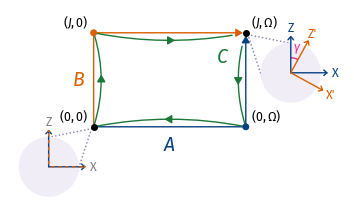

In [12]:
trans = (
    fig.dpi_scale_trans +
    mpl.transforms.ScaledTranslation(
        1.0,
        1.0,
        ax.transData,
    )
)

circle = mpl.patches.Circle(
    (0.45, -0.4),
    0.3,
    transform=trans,
    fc=bloch_sphere_color,
    ec='none',
    zorder=10,
)
ax.add_patch(circle)
cone = mpl.patches.FancyArrowPatch(
    posA=0.8*np.array([0.45, -0.4]),
    posB=(0, 0),
    transform=trans,
    arrowstyle='wedge,tail_width=38',
    shrinkA=0.0,
    edgecolor=bloch_dark_color,
    facecolor='none',
    ls=':',
    capstyle='butt',
    zorder=-10,
)
ax.add_patch(cone)

z_axis = mpl.patches.FancyArrowPatch(
    posA=(0.45, -0.4),
    posB=(0.45, 0.0),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color0,
    zorder=100,
)
ax.add_patch(z_axis)
x_axis = mpl.patches.FancyArrowPatch(
    posA=(0.45, -0.4),
    posB=(0.85, -0.4),
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color0,
    zorder=100,
)
ax.add_patch(x_axis)

z_label = mpl.text.Text(
    x=0.45,
    y=0.05,
    text="Z",
    transform=trans,
    color=color0,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(z_label)

x_label = mpl.text.Text(
    x=0.90,
    y=-0.40,
    text="X",
    transform=trans,
    color=color0,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(x_label)

posA = np.array([0.45, -0.4])
angle = -0.5
posB = posA + 0.4 * np.array([-np.sin(angle), np.cos(angle)])
z_axis = mpl.patches.FancyArrowPatch(
    posA=posA,
    posB=posB,
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color1,
    zorder=100,
)
ax.add_patch(z_axis)

posB = posA + 0.4 * np.array([np.cos(angle), np.sin(angle)])
x_axis = mpl.patches.FancyArrowPatch(
    posA=posA,
    posB=posB,
    transform=trans,
    arrowstyle='->,head_width=2,head_length=2.3',
    shrinkA=0.0,
    color=color1,
    zorder=100,
)
ax.add_patch(x_axis)

pos = posA + 0.45 * np.array([-np.sin(angle), np.cos(angle)])
z_label = mpl.text.Text(
    *pos,
    text="Z'",
    transform=trans,
    color=color1,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(z_label)

pos = posA + 0.45 * np.array([np.cos(angle), np.sin(angle)])
x_label = mpl.text.Text(
    *pos,
    text="X'",
    transform=trans,
    color=color1,
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(x_label)


pos = posA + 0.25 * np.array([-np.sin(angle/2), np.cos(angle/2)])
angle_label = mpl.text.Text(
    *pos,
    text="$\gamma$",
    transform=trans,
    color='C5',
    ha='center',
    va='center',
    zorder=1000,
)
ax.add_artist(angle_label)

arc = mpl.patches.Arc(
    posA,
    0.3,
    0.3,
    theta1=90 + np.degrees(angle),
    theta2=90,
    ec='C5',
    fc='none',
    lw=plt.rcParams['lines.linewidth'],
    transform=trans,
    zorder=99,
)
ax.add_patch(arc)

fig

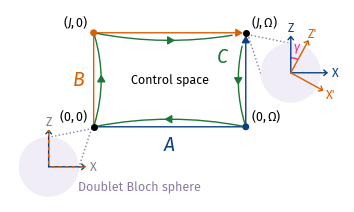

In [13]:
annotation = ax.annotate(
    "Control space",
    (0.5, 0.5),
    (0, 0),
    textcoords='offset points',
    ha='center',
    va='center',
)

annotation = ax.annotate(
    "Doublet Bloch sphere",
    (0, 0),
    (-11, -48),
    textcoords='offset points',
    c=bloch_dark_color,
    ha='left',
    va='bottom',
    zorder=1000,
)

fig

In [14]:
fig.savefig("parallel_transport.pdf")